In [1]:
from namap_main import *
import matplotlib.pyplot as plt
from astropy.visualization import ZScaleInterval

In [2]:
P = ld.load_params('PAR_FILES/params_namap.par')

_prec = str(P['precision'].lower()) #Select the precision: 64, 32 or 16B

num_frames, first_frame = P['num_frames'], P['first_frame'] #frames to be loaded
#1 frame is defined as 1 second of integration time. 

if P['input_ctype'] == 'RA and DEC':
    coord1 = str('RA')
    coord2 = str('DEC')
    xystage = False

elif P['input_ctype'] == 'AZ and EL':
    coord1 = str('AZ')
    coord2 = str('EL')
    xystage = Falsedetector_table = 'config/TIM_kid_table.tsv' 

elif P['input_ctype'] == 'CROSS-EL and EL':
    coord1 = str('xEL')
    coord2 = str('EL')
    xystage = False
elif P['input_ctype'] == 'XY Stage':
    coord1 = str('X')
    coord2 = str('Y')
    xystage = True

#Pre-processing parameters for TODs
highpassfreq = P['highpassfreq']
polynomialorder = P['polynomialorder']
despike_bool = P['despike']
sigma,prominence = P['sigma'],P['prominence']
sigma_clipping_bool = ['sigma_clipping']
low_thresh, high_thresh = P['low_thresh'], P['high_thresh'] 
if(P['downsample_frequency'] is not None): downsample = True
else: downsample = False
#Beam convolution parameters
convolution, std = P['gaussian_convolution'], P['std'] 


In [3]:
dtype_map = {
    '16': np.float16, 'float16': np.float16, 'half': np.float16,
    '32': np.float32, 'float32': np.float32, 'single': np.float32,
    '64': np.float64, 'float64': np.float64, 'double': np.float64
}

int_map = {
    '16': np.int16, 'float16': np.int16, 'half': np.int16,
    '32': np.int32, 'float32': np.int32, 'single': np.int32,
    '64': np.int64, 'float64': np.int64, 'double': np.int64
}

try:
    DT = dtype_map[_prec]
    IT = int_map[_prec]
except KeyError:
    raise ValueError(f"Unsupported precision '{_prec}'. Choose float16/32/64 or 16/32/64.")
print(f"Using numeric dtype: {DT}")

Using numeric dtype: <class 'numpy.float64'>


In [4]:
#Load the name of the KIDs to be analyse. 

filepath = P['input_file']
btable = tb.Table.read(P['detector_table'], format='ascii.tab')

# Select detectors from the good-behaving detector list
if P['detectors_to_use'] is not None:
    good_kid_table = tb.Table.read(P['detectors_to_use'], format='ascii.tab')
    filtered = btable[np.isin(btable['Name'], good_kid_table['Name'])]

# Select detectors per observed E.M frequency
if P['frequencies'] is not None: filtered = btable[np.isin(btable['Frequency'], P['frequencies'])]

if P['frequencies'] is None and P['detectors_to_use'] is None: filtered = btable

kid_num = filtered['Name']
print('Number of detectors: ', len(kid_num))

Number of detectors:  51


COORDINATES az el
The number of samples loaded per frame for the detectors is: 100, and one frame is 1 second, so the spf is the rounded aquisition frequency


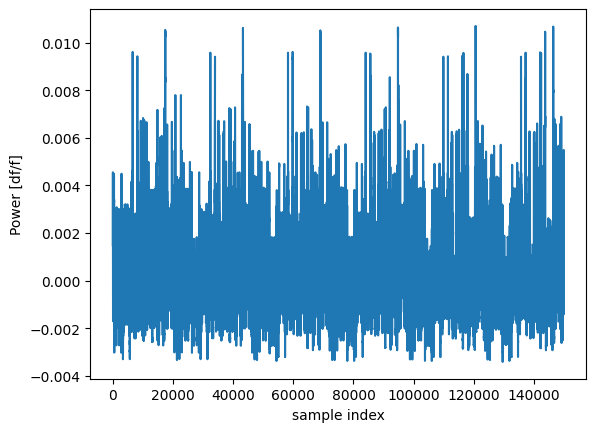

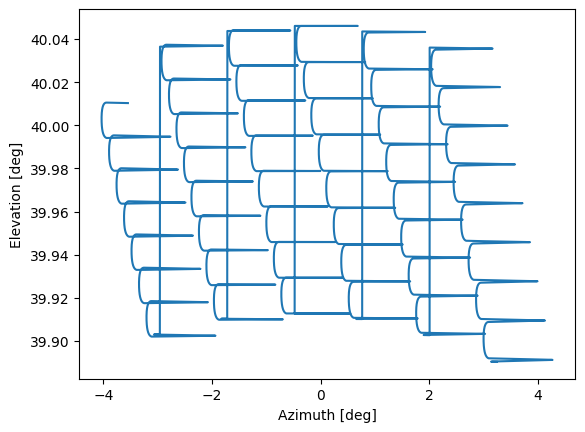

In [5]:
#load the timestreams and the coordinates. 

dataload = ld.data_value( det_path=filepath, det_name=kid_num, coord1_name=coord1, coord2_name=coord2, startframe=first_frame,
                numframes=num_frames, despike=despike_bool, sigma=sigma, prominence=prominence, downsample=downsample, freq_target=P['downsample_frequency'],
                DT=DT, IT=IT)
timemap, det_data, ctime, coord1_data, coord2_data, turnaround_flags, lst_data, lat_data, spf_data, spf_coord, lat_spf = dataload.values()

plt.plot(det_data[0])
plt.xlabel('sample index')
plt.ylabel('Power [df/f]')

plt.figure()
plt.plot(coord1_data, coord2_data,)
plt.xlabel('Azimuth [deg]')
plt.ylabel('Elevation [deg]')
print(f'The number of samples loaded per frame for the detectors is: {spf_data:.0f}, and one frame is 1 second, so the spf is the rounded aquisition frequency')

In [6]:
det_tod = tod.data_cleaned(det_data, kid_num, spf_data, 
                        highpassfreq, polynomialorder, 
                        False, 0, 0, 
                        sigma_clipping_bool, low_thresh,high_thresh, 
                        DT)

cleaned_data, kid_num, rejected_detetectors_list = det_tod.data_clean()

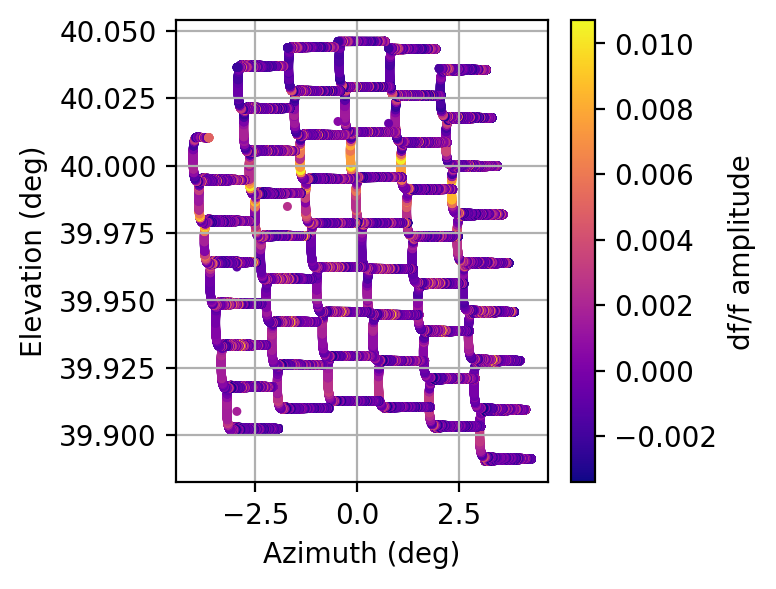

In [7]:
#Synchronize data with coordinates and downsample the timestreams to freq_target in Hz. 

zoomsyncdata = ld.frame_zoom_sync(timemap, cleaned_data, spf_data, ctime, coord1_data, coord2_data, spf_coord, 
                                    turnaround_flags, lst_data, lat_data,  lat_spf,  DT, IT)                
timemap, cleaned_data, coord1_data, coord2_data, lst_data, lat_data, turnaround_flags = zoomsyncdata.sync_data() 


#Filter out the turnarounds
if(P['remove_turnarounds']):
    for i in range(len(cleaned_data)): cleaned_data[i] = cleaned_data[i][turnaround_flags==1]
    if P['save_downsampled_TODS']: timemap = timemap[turnaround_flags==1]
    lst_data = lst_data[turnaround_flags==1]
    lat_data = lat_data[turnaround_flags==1]
    coord2_data = coord2_data[turnaround_flags==1]
    coord1_data = coord1_data[turnaround_flags==1] 

# === Plot Az vs Alt with data amplitude as color ===
fig, ax = plt.subplots(figsize=(3,3), dpi=200)

sc = ax.scatter(coord1_data, coord2_data, c=cleaned_data[0], cmap='plasma', s=5)
# Attach colorbar to the left subplot (axs[0])
ax.set_xlabel('Azimuth (deg)')
ax.set_ylabel('Elevation (deg)')
ax.grid(True)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('df/f amplitude')

In [8]:
#Save the timestreams
tods_compressor = ld.save_tods(P['output_tods'], 
                                kid_num, cleaned_data, spf_data, timemap, 
                                coord1, coord2, coord1_data, coord2_data, spf_data,timemap,
                                first_frame, num_frames, lst_data, lat_data,P,            
                                DT, IT)
tods_compressor.fct_save_tods()

Removed existing directory: datasets/tods
dirfile is: datasets/tods


In [9]:

#load the table of detector offsets
dettable = ld.det_table(kid_num, P['detector_table']) 
det_off, _,_ = dettable.loadtable() #noise_det, resp

#Offset with respect to star cameras in xEL and EL
xsc_offset = (P['xsc_offset'],P['det_offset']) #needs to be tested with real offsets. 


In [10]:

corr = pt.apply_offset(P['input_ctype'], coord1_data, coord2_data, P['ctype'], xsc_offset, DT,IT, det_offset = det_off, lst = lst_data, lat = lat_data, )
coord1slice, coord2slice = corr.correction()


/home/mvancuyck/Desktop/TIM_analysis/namap/src/mapmaker.py:473: RuntimeWarning: invalid value encountered in divide
  flux /= hits
/home/mvancuyck/Desktop/TIM_analysis/namap/src/mapmaker.py:481: RuntimeWarning: invalid value encountered in divide
  hist /= norm


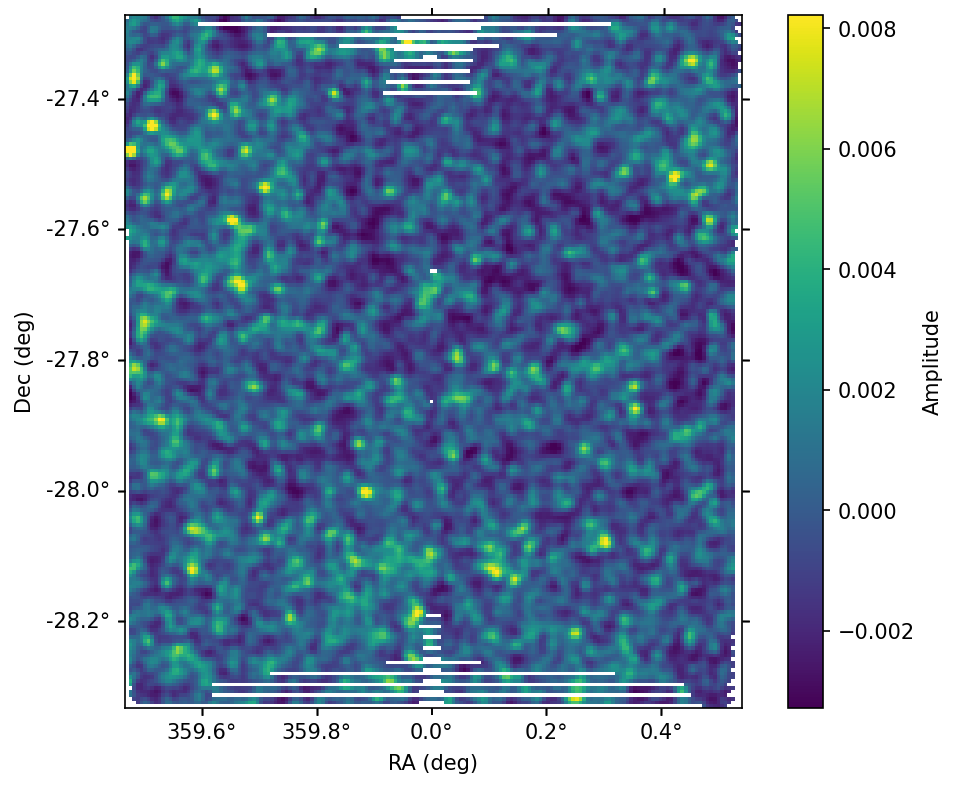

In [11]:
# create the maps and save them in fits_and_hdf5/ 
#--------------------
coadd = True #If True, coadd all detectors into one map. Else, save individual detector maps. 
#-------------------
parallactic=[]
if P['telescope_coordinate']:
    for j, (c1, c2) in enumerate(zip(coord1slice,coord2slice)): 
        tel = pt.utils(c1, c2, lst_data, lat_data)
        parallactic.append( tel.parallactic_angle() )
else:
    for j, (c1, c2) in enumerate(zip(coord1slice,coord2slice)): 
        parallactic.append(np.zeros_like(c1, dtype=DT))

#---------------------------------

#--------------------
#Create the maps
maps = mp.maps(P['ctype'], 
            np.asarray([P['crpix'][0],P['crpix'][1]]), 
            np.asarray([P['cdelt'][0],P['cdelt'][1]]), 
            np.asarray([P['crval'][0], P['crval'][1]]), 
            np.asarray([P['pixnum'][0],P['pixnum'][1]]), 
            cleaned_data, coord1slice, coord2slice, convolution, std, P['output_map'], DT,IT,
            coadd=coadd,   parang=parallactic, params=str(P)) #noise=noise_det,telcoord = P['telescope_coordinate'],

maps.wcs_proj()
wcs = maps.w
map_values = maps.map2d()
#--------------------


zscale = ZScaleInterval()
vmin, vmax = zscale.get_limits(map_values)
fig, ax = plt.subplots(dpi=150,figsize=(8, 6),subplot_kw={'projection': wcs})
img = ax.imshow(map_values, origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)
ax.set_xlabel('RA (deg)')
ax.set_ylabel('Dec (deg)')
ax.coords[0].set_format_unit('deg', decimal=True)  # RA
ax.coords[1].set_format_unit('deg', decimal=True)  # De
fig.colorbar(img, ax=ax, label='Amplitude')
plt.show()
